# Analisi di telemetria di F1

<h2>Dennis Cokaj</h2> 

# Introduzione

* **Perchè:** elevata densità e disponibilità di dati telemetrici ad alta frequenza.
  
* **Obiettivo:** valutare quanto il pilota e le sue decisioni influenzino i risultati.

# Caso studio 

* **Circuito:** GP di Silverstone in Gran Bretagna.

* **Target:** confronto interno al team Mercedes tra George Russel e Kimi Antonelli. 
* **Metodologia:** Analizzare la stessa monoposto per isolare la sola componente guida.


## Domande di ricerca: ##

_Il divario nei tempi d'arrivo rispecchiano una reale differenza nelle prestazioni di guida?_

_In quali parametri operativi emergono le principali divergenze tra i due piloti?_

# Descrizione dei dati

* **Dataset analizzato:** Telemetrie ufficiali della F1, Ricavati tramite interfaccia open source FastF1 (theOehrly su GitHub)

* **Dati:** Dati di bordo inerenti alla guida del pilota.

* **Dati non presenti:** Parametri interni riservati alle scuderie.

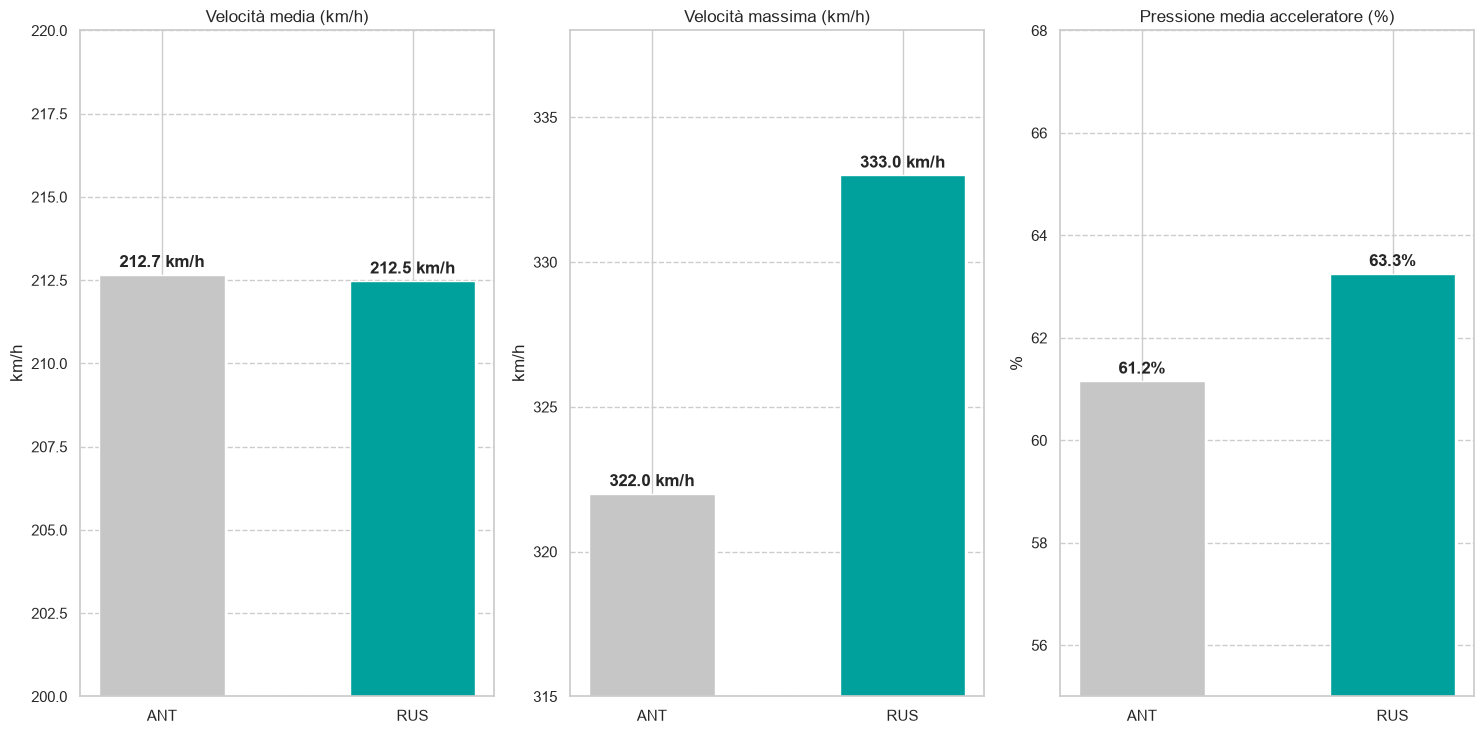

In [60]:
import seaborn as sns
sns.set_theme(style="whitegrid")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.image as mpimg
import os
import fastf1

dataset_nonp= pd.read_csv('telemetria_mercedes.csv')


# elimino pit-stop 
dataset_pulito =dataset_nonp[dataset_nonp['Speed'] > 80].copy()

#calcolo valori max e medi sul dataset pulito
dataset_processato = dataset_pulito.groupby('Pilota').agg(  # ( .agg mi serviva ad applicare funzioni)
    Velocità_media=('Speed', 'mean'),
    Velocità_max=('Speed', 'max'),
    Acceleratore_medio =('Throttle', 'mean')
).reset_index()  # rimetto le colonne dei piloti

# creo la base
figura, (vel, vmax, acc) = plt.subplots(1, 3, figsize=(15, 7.5)) # 1 riga e tre colonne + la misura in pollici 

# grafico velocità media, azzurro russel e grgio kimi
barra_velocità= vel.bar(dataset_processato['Pilota'],               # x
                         dataset_processato['Velocità_media'],      # altezza
                         color =['#c6c6c6', '#00a19c'],
                         width=0.5)

vel.set_title('Velocità media (km/h)')

vel.set_ylabel('km/h')
vel.grid(axis ='y', linestyle='--')
vel.bar_label(barra_velocità,
              fmt='%.1f km/h',
              padding= 3,
              fontweight='bold')
           
#grafico accellerazione
barra_accellerazione =acc.bar(dataset_processato['Pilota'], 
                               dataset_processato['Acceleratore_medio'],
                               color=['#c6c6c6', '#00a19c'],
                               width=0.5)
acc.set_title('Pressione media acceleratore (%)')
acc.set_ylabel('%')
acc.grid(axis='y', linestyle = '--')
acc.bar_label(barra_accellerazione, fmt='%.1f%%', padding=3, fontweight='bold')

# velocità massima:
barra_vmax = vmax.bar(dataset_processato['Pilota'], 
                        dataset_processato['Velocità_max'],
                        color=['#c6c6c6', '#00a19c'],
                        width=0.5)

vmax.set_title('Velocità massima (km/h)')
vmax.set_ylabel('km/h')
vmax.grid(axis= 'y', linestyle='--')
vmax.bar_label(barra_vmax, fmt='%.1f km/h', padding= 3, fontweight='bold')

vel.set_ylim(200, 220)   
vmax.set_ylim(315, 338) 
acc.set_ylim(55, 68)

plt.tight_layout() # per evitare che si sovrapponga
plt.show()


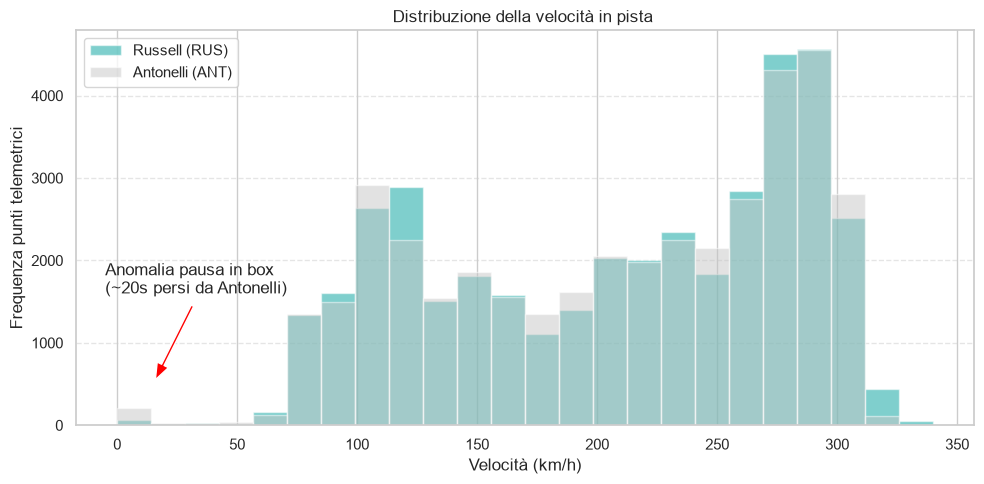

In [87]:
# colonne velocità di entramvi
velocità_russel = dataset_nonp[dataset_nonp['Pilota'] == 'RUS']['Speed']  
velocita_antonelli = dataset_nonp[dataset_nonp['Pilota'] == 'ANT']['Speed']  

#isto
figura2, vel2 =plt.subplots(figsize=(10, 5)) 
intervalli_comuni = np.linspace(0, 340, 25)

vel2.hist(
    velocità_russel,
    bins =intervalli_comuni,
    alpha=0.5,
    label= 'Russell (RUS)',
    color='#00a19c', 
)

vel2.hist(
    velocita_antonelli, # x
    bins=intervalli_comuni,
    alpha=0.5,
    label='Antonelli (ANT)',
    color='#c6c6c6',
)

vel2.set_title('Distribuzione della velocità in pista ')
vel2.set_xlabel('Velocità (km/h)')
vel2.set_ylabel('Frequenza punti telemetrici')
vel2.grid(axis='y', linestyle = '--', alpha=0.5)
vel2.legend()
vel2.annotate('Anomalia pausa in box\n(~20s persi da Antonelli)',
             xy=(15, 500),
             xytext=(-5, 1600),
             arrowprops=dict(facecolor='red',
                             shrink=0.05,
                             width=2,
                             headwidth=9)
            )

plt.tight_layout()
plt.show()

In [62]:
monogiro = dataset_pulito[dataset_pulito['Distance'] <= 5891].copy()
monogiro['DistanzaArrotondata']= (monogiro['Distance'] / 100).round() * 100
profilo= monogiro.groupby(['DistanzaArrotondata', 'Pilota'])['Speed'].mean().unstack()

figura, curva=plt.subplots(figsize=(7, 5))

curva.plot(
    profilo.index,
    profilo['RUS'],
    label ='Russell (RUS)',
    color='#00a19c',
    linewidth=2,
)

curva.plot(
    profilo.index,
    profilo['ANT'],
    label = 'Antonelli (ANT)',
    color='#C6c6c6',
    linewidth=2,
    linestyle='--',
)

curva.set_title(
    'Profilo di velocità media',
    fontweight='bold'
    )

curva.set_xlabel('Distanza lungo la pista (metri)')
curva.set_ylabel('Velocità Media (km/h)')
curva.set_xlim(0, 5891)

curva.grid(True, linestyle=':', alpha=1)
curva.legend()

plt.tight_layout()
os.makedirs('img', exist_ok= True)
plt.savefig('img/grafico_velocita.png', dpi=300, bbox_inches='tight')

plt.close()

<div style="display: flex; justify-content: space-between; align-items: center; width: 100%; gap: 10px;">
  <div style="width: 49%;">
    <img src="img/grafico_velocita.png" style="width: 100%; height: auto;" alt="grafico velocità">
  </div>
  <div style="width: 49%;">
    <img src="img/Circuit_Silverstone_2011.svg" style="width: 100%; height: auto;" alt="mappa pista Silverstone">
  </div>
</div>

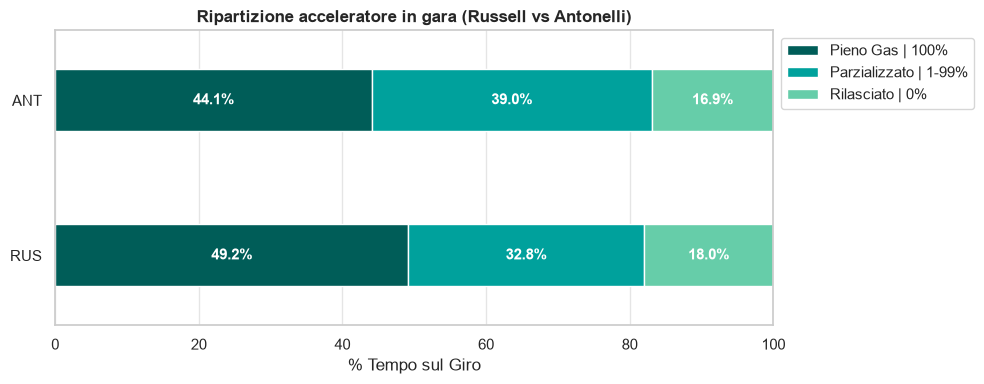

In [63]:
dataset_pulito2 =dataset_pulito[dataset_pulito['Throttle'] <=100].copy() #cerano valori tipo 103 104 COL freno, e la velocità era fissa quindi forse bug?

def definisci_quanto(val):
    if val >= 100: 
        return 'Pieno Gas | 100%'
    elif val > 0 and val < 100:
        return 'Parzializzato | 1-99%'
    else:
        return 'Rilasciato | 0%'

dataset_pulito2['quanto_gas'] = dataset_pulito2['Throttle'].apply(definisci_quanto)

QuantoRussel = dataset_pulito2[dataset_pulito2['Pilota'] == 'RUS']['quanto_gas'].value_counts(normalize=True) * 100
QuantoAntonelli =dataset_pulito2[dataset_pulito2['Pilota']== 'ANT']['quanto_gas'].value_counts(normalize=True) * 100

categorie=['Pieno Gas | 100%', 'Parzializzato | 1-99%', 'Rilasciato | 0%']
mercedes = pd.DataFrame([QuantoRussel, QuantoAntonelli], index=['RUS', 'ANT'])[categorie]

figura3, accelleratore = plt.subplots(figsize=(10, 4))
colori= ['#005d58',
          '#00a19c',
          '#66cda9']

mercedes.plot(kind= 'barh', #per lorizzontale
              stacked=True,
              color=colori,
              ax=accelleratore,
              width=0.4)

accelleratore.set_title('Ripartizione acceleratore in gara (Russell vs Antonelli)',
                        fontweight ='bold',
                        fontsize= 12)
accelleratore.set_xlabel('% Tempo sul Giro')
accelleratore.set_xlim(0, 100)
accelleratore.legend(bbox_to_anchor=(1, 1), loc='upper left')
accelleratore.grid(alpha=0.5)

for container in accelleratore.containers:
   accelleratore.bar_label(container,
                           fmt='%.1f%%',
                           label_type = 'center',
                           color='white',
                           fontweight='bold',
                           fontsize=11)

plt.tight_layout()
plt.show()

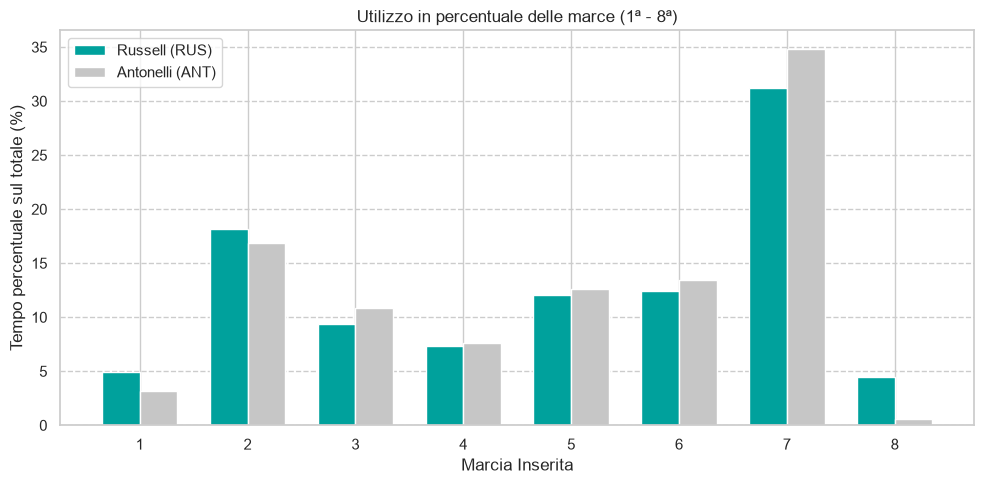

In [88]:
marce_russel =dataset_pulito[dataset_pulito['Pilota'] == 'RUS']['nGear'].value_counts(normalize=True) 
marce_antonelli = dataset_pulito[dataset_pulito['Pilota']== 'ANT']['nGear'].value_counts(normalize=True) 

dataset_marce=pd.DataFrame({'RUS': marce_russel, 'ANT': marce_antonelli}).sort_index()

figure, marx = plt.subplots(figsize =(10, 5))

marx.bar(
    dataset_marce.index - 0.35 / 2,  
    dataset_marce['RUS'] * 100,  
    width=0.35,
    label ='Russell (RUS)',
    color = '#00A19C',
)

marx.bar(
    dataset_marce.index+ 0.35 / 2,  
    dataset_marce['ANT'] * 100,  
    width= 0.35,
    label='Antonelli (ANT)',
    color= '#C6C6C6',
)

marx.set_title('Utilizzo in percentuale delle marce (1ª - 8ª)')
marx.set_xlabel('Marcia Inserita')
marx.set_ylabel('Tempo percentuale sul totale (%)')
marx.set_xticks(dataset_marce.index)
marx.grid(axis= 'y', linestyle='--')
marx.legend()

plt.tight_layout()
plt.show()

# Conclusione

* **Impatto eventi vs guida:** Il divario di tempo finale è condizionato dall'anomalia del pit-stop e non da un deficit di passo strutturale.

* **Conclusione data science:** L'analisi telemetrica dimostra come i soli dati di classifica siano fuorvianti senza una corretta fase di analisi.
---
<small>Nota: mappa del tracciato di Silverstone (Layout Grand Prix 2011-presente).</small>

In [19]:
conteggio_104 = (dataset_nonp['Throttle'] == 104).sum()
conteggio_sopra_100 = (dataset_nonp['Throttle'] > 100).sum()

print(f"Punti con 104: {conteggio_104}")
print(f"Punti > 100%: {conteggio_sopra_100}")

Punti con 104: 134
Punti > 100%: 147


In [20]:
intervalli = pd.to_datetime(dataset_nonp['Date']).diff().dt.total_seconds()

frequenza_hz = 1 / intervalli.mean()
print(f"frequenza campionamento media: {frequenza_hz:.2f} Hz")

frequenza campionamento media: 15.02 Hz
